<font size="5.8">Hands-On Multi-Agent Systems with LangGraph Integrating MCP Servers</font>  

Agents in Production

How to move from prototype to production system:
- Covering Multi-Agent Architectures
- Using Model Contect Protocol (MCP) to empower agents
- Packeging end to end multi-agent AI SDR with Docker, MCP and LangGraph 

Python functions and data files needed to run this notebook are available via this [link](https://github.com/MehdiRezvandehy/agentic_workflow_crewai_langchain.git).

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Multi-agent-Systems-(Architectures)" data-toc-modified-id="Multi-agent-Systems-(Architectures)-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Multi-agent Systems (Architectures)</a></span></li><li><span><a href="#Create-Agent-Tools" data-toc-modified-id="Create-Agent-Tools-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Create Agent Tools</a></span></li><li><span><a href="#Any-to-Any-Multi-Agent-Networks" data-toc-modified-id="Any-to-Any-Multi-Agent-Networks-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Any-to-Any Multi-Agent Networks</a></span></li><li><span><a href="#Supervisor-Multi-Agents" data-toc-modified-id="Supervisor-Multi-Agents-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Supervisor Multi-Agents</a></span></li><li><span><a href="#Supervisor-Tool-Calling-Multi-Agents" data-toc-modified-id="Supervisor-Tool-Calling-Multi-Agents-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Supervisor Tool Calling Multi-Agents</a></span></li><li><span><a href="#Using-MCP-to-Enhance-Agent-Capabilities" data-toc-modified-id="Using-MCP-to-Enhance-Agent-Capabilities-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Using MCP to Enhance Agent Capabilities</a></span><ul class="toc-item"><li><span><a href="#LangGraph-Specific-Setup" data-toc-modified-id="LangGraph-Specific-Setup-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>LangGraph-Specific Setup</a></span></li><li><span><a href="#Incorporating-MCP-into-the-architecture" data-toc-modified-id="Incorporating-MCP-into-the-architecture-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Incorporating MCP into the architecture</a></span><ul class="toc-item"><li><span><a href="#Local-MCP-Server" data-toc-modified-id="Local-MCP-Server-6.2.1"><span class="toc-item-num">6.2.1&nbsp;&nbsp;</span>Local MCP Server</a></span></li><li><span><a href="#Remote-MCP-Server" data-toc-modified-id="Remote-MCP-Server-6.2.2"><span class="toc-item-num">6.2.2&nbsp;&nbsp;</span>Remote MCP Server</a></span></li></ul></li></ul></li><li><span><a href="#Summary" data-toc-modified-id="Summary-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Summary</a></span><ul class="toc-item"><li><span><a href="#Risk-Using-MCP" data-toc-modified-id="Risk-Using-MCP-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>Risk Using MCP</a></span></li></ul></li></ul></div>

# Multi-agent Systems (Architectures)

Sometimes, a single agent is not enough. A single agent typically works sequentially, executing tools one after another. As the number of tools available to an agent increases, the agent can become confused about which tool to use. This can result from overly long prompts, excessive guardrails, too many tool calls, detailed tool descriptions, or even tool hallucinations.

One way to address this problem is through a multi-agent system, where multiple agents work together collaboratively. There are many different ways to design and architect multi-agent systems.

The concept of an agent itself remains the same as a standard ReAct agent: it includes prompts, context, instructions, and tools. In other words, an agent is simply a combination of prompts, tools, and reasoning capabilities—nothing fundamentally different.

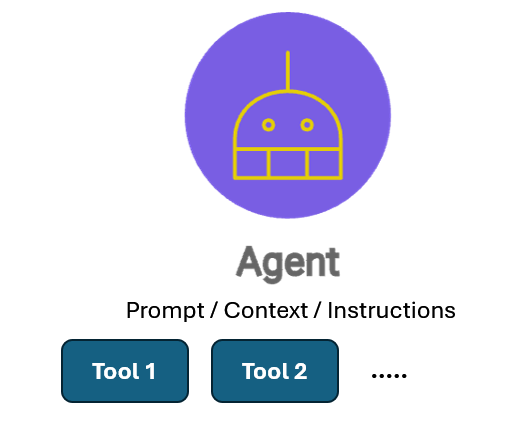

There are three common ways of constructing multi-agent systems:

1. **Any-to-any Networks**

   It has the simplest and most flexible multi-agent design. In this setup, every agent has full autonomy to pass the entire conversation history to any other agent at any time. This approach is straightforward and somewhat naïve: each agent can see everything that has happened so far and can decide independently who should handle the next step. For example, a coding agent (Python) might pass the full conversation to a math agent, or a web-retrieval agent, depending on the task.
   
   The main advantage is simplicity. You don’t need to worry about managing or filtering context—every agent always has full visibility into the conversation. However, this comes with important trade-offs.
   
   First, each agent now carries additional responsibility. Beyond performing its core task, it must also decide when and where to route the conversation next. This increases system complexity and can lead to poor decisions if agents are not well-designed for coordination.
   
   Second, there is a cost and efficiency concern. Some agents are intentionally lightweight—designed to be fast and inexpensive for simple tasks. Expecting them to also handle routing decisions (often implemented via tool-calling) adds overhead and can negate their efficiency benefits.
   
   While this architecture is easy to implement, it is often not the most efficient or scalable approach. More structured designs can reduce cost, improve reliability, and better separate responsibilities across agents.

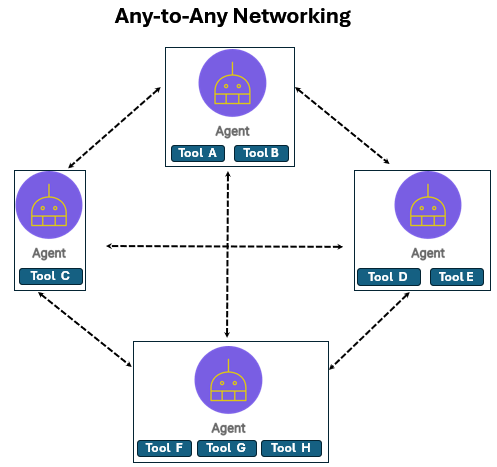

2. **Supervisor Networks**

   Supervisor networks are a type of multi-agent architecture in which a central supervisor agent manages and coordinates all interactions between sub-agents. The supervisor is responsible for task delegation, routing decisions, and controlling the overall workflow, while sub-agents focus only on executing their assigned tasks.
   
   A key caveat of **supervisor networks** is that they are not always the optimal architectural choice. However, in practice, when people build multi-agent systems, a large portion of them—arguably around 70%—end up implementing some form of supervised architecture, even if unintentionally.
   
   In a supervisor network, a central supervisor agent orchestrates the flow of communication between agents. Messages may still pass between agents, but the critical constraint is that only the supervisor controls these transitions. In other words, the supervisor is responsible for deciding which agent should handle each stage of the task.
   
   In some implementations, conversation history may be truncated or summarized to keep interactions concise. However, in a pure supervisor architecture, the workflow follows a strict pattern: the supervisor assigns a task to a sub-agent, the sub-agent performs the assigned work, and **then control is always returned to the supervisor**.
   
   Sub-agents do not make routing or coordination decisions. Their responsibility is limited to executing the task they receive. Typically, each sub-agent is provided with the relevant context along with a clear instruction from the supervisor. After completing the task, the sub-agent reports the results back to the supervisor, which then determines the next step in the workflow.
   
   As a result, all coordination, routing, and high-level decision-making remain centralized within the supervisor agent.


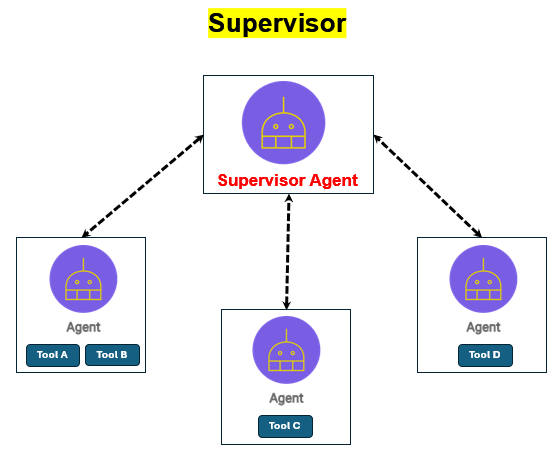

3. **Supervisor Tool-Calling**

   A hybrid variation of the supervisor model is **supervisor tool-calling**. It still follows the same overall structure—there is a supervisor, sub-agents, and task delegation—but the interaction pattern is different.
   
   Instead of passing the full conversation to sub-agents, the supervisor treats them as tools. Rather than saying, “Here is the entire conversation, handle the next step,” the supervisor keeps control of the dialogue with the user and only engages sub-agents when needed. In those moments, it communicates with them privately, providing just the specific context required to complete a task.
   
   In this setup, the supervisor acts as a strict gatekeeper. Sub-agents do not see the full conversation—only the relevant pieces necessary for their task. This leads to significant efficiency gains: less context to process means lower cost, faster responses, and more focused execution. In many ways, sub-agents behave like specialized “ReAct-style” tools that perform well-defined actions.
   
   However, this design also introduces a trade-off. The system now relies heavily on the supervisor’s ability to provide the right context at the right time. Even if powered by a strong reasoning LLM, the **supervisor can still omit important details**. Sub-agents typically proceed with whatever context they are given and are not always designed to question missing information. To mitigate this, you can equip sub-agents with a mechanism (e.g., a tool or protocol) to request additional context when needed.

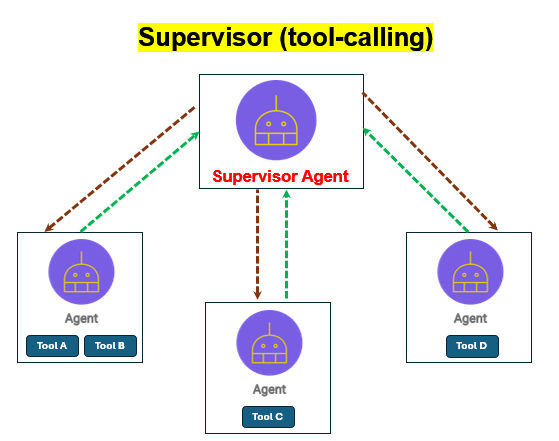

The key question is when to use each of these architectures.

- A **centralized (supervisor-based) model** works best for structured, enterprise workflows—such as SDR (Sales Development Representative) pipelines—where tasks are predictable, sequential, and need tight control.

- A **decentralized (any-to-any) model** is better suited for creative or exploratory scenarios, like collaborative research. In these cases, agents benefit from autonomy and flexibility—there’s no strict order, and they can decide how to approach the problem. For example, asking an agent to “go figure out the best way to solve this” fits well here, whereas a task like drafting an email is more straightforward and doesn’t require that level of freedom.


- The **supervisor-as-tool-caller** architecture sits in the middle, balancing control and flexibility by centralizing coordination while keeping sub-agents focused and efficient.


Here is LangGraph implementation for the three constructing multi-agent systems:

In [4]:
import os

# Load environment variables (e.g., OPENAI_API_KEY)
from dotenv import load_dotenv
load_dotenv(override=True)

# Load API keys
# Provide your credentials and API keys in a `.env` file to authenticate services
#(OpenAI API key, email credentials, Tavily API key).
os.environ['OPENAI_API_KEY'] = os.environ.get("OPENAI_API_KEY")
os.environ["SERP_API_KEY"] = os.environ.get("SERP_API_KEY")

**In cyclic “any-to-any” graphs, LangGraph will NOT auto-stop just because an answer exists.**

# Create Agent Tools 

In [5]:
import warnings
warnings.filterwarnings('ignore')
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from pydantic import BaseModel
from langgraph.prebuilt import InjectedState, create_react_agent

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [6]:
from rich.console import Console
from rich.markdown import Markdown
import re

console = Console()

def format_workflow_activity(activity_log):
    """Generate formatted workflow activity text."""

    output = []

    for worker_id, worker_data in activity_log.items():

        output.append(f"\n# 🤖 Agent: {worker_id}\n")

        if "messages" not in worker_data:
            continue

        conversation_items = worker_data["messages"]

        if not isinstance(conversation_items, list):
            conversation_items = [conversation_items]

        for item in conversation_items:

            # AI messages
            if isinstance(item, AIMessage):

                if item.content:
                    output.append(f"💬 **Response:** {item.content}\n")

                if hasattr(item, "tool_calls") and item.tool_calls:

                    for action in item.tool_calls:

                        action_name = action["name"]
                        action_args = action["args"]
                        output.append(
                                f"🔧 **Tool:** `{action_name}` | Args: `{action_args}`\n")

            # Tool messages
            elif isinstance(item, ToolMessage):

                if item.content != "None":
                    output.append(f"⚙️ **Tool Result:** {item.content}\n")

    return "\n".join(output)

In [7]:
import json
import os
import requests
from langchain.tools import BaseTool
from serpapi import GoogleSearch

class GoogleSearchTool(BaseTool):
    name: str = "Google Search"
    description: str = """Searches the internet for a given topic and returns relevant results."""

    def _run(self, query: str, top_k: int = 3) -> str:
        params = {
            "engine": "google",
            "google_domain": "google.com",
            "gl": "us",
            "hl": "en",
            "q": query,
            "api_key": os.environ["SERP_API_KEY"],
        }

        search = GoogleSearch(params)
        response = search.get_dict()
        
        # Check if organic results are available, exclude sponsored results
        if 'organic_results' not in response:
            return "Sorry, I couldn't find anything on that topic. There may be an issue with your SerpApi key."
        
        results = response['organic_results']
        formatted_results = []
        
        for result in results[:top_k]:
            try:
                formatted_results.append('\n'.join([
                    f"Title: {result['title']}", 
                    f"Link: {result['link']}",
                    f"Snippet: {result['snippet']}", 
                    "\n-----------------"
                ]))
            except KeyError:
                continue

        return '\n'.join(formatted_results)

In [8]:
from langchain_experimental.tools.python.tool import PythonREPLTool
from langchain_core.tools import tool

# Tool for Python code
python_tool = PythonREPLTool(name='Python_REPL',
                                  description= 'A Python shell. Use this to execute python commands. \
                                  Input should be a valid python command. If you want to see the \
                                  output of a value, you should print it out with `print(...)`.',
                                  return_direct = False,
                                  verbose = True)
    
# Tool for google search
@tool
def google_search_scrape(input_str: str) -> str:
    """
    Given a user's full query, apply google search
    and answer the question using the search.
    """
    print("INPUT TO TOOL:", input_str)
    # Extract URL
    google_content = GoogleSearchTool().run(input_str)

    return google_content

In [9]:
from langchain_openai import ChatOpenAI

# Model used for Any-to-Any Multi-Agent Networks
model = ChatOpenAI(model='gpt-4o-mini')

# -------------------------------------------------------------------
# 🔷 AGENT CONFIGURATION
# -------------------------------------------------------------------

agents = {
    # ============================================================
    # 🧠 SYMBOLIC REASONING AGENT
    # ============================================================
    "symbolic_reasoning_agent": (
        model,
        [],
        "Handles logical reasoning, algebraic manipulation, derivations, and problem decomposition.",
        "You are a symbolic reasoning expert. You do NOT write code. "
        "You reason step-by-step using logic, algebra, and mathematical transformations. "
        "You focus on understanding structure, deriving formulas, and explaining reasoning clearly."
    ),

    # ============================================================
    # 🌐 GOOGLE SEARCH AGENT (STRICT GROUNDED QA)
    # ============================================================
    "google_search_agent": (
        model,
        [google_search_scrape],
        "Retrieves information using Google search and answers ONLY from retrieved results.",
        """
You are a STRICT retrieval-based search agent.

DO NOT:
- Write Python code
- Perform calculations
- Forecast values
- Answer the user's full request

Workflow:
1. Read search results
2. Extract relevant facts
3. Return final answer strictly based on them
"""
    ),

    # ============================================================
    # 🐍 PYTHON AGENT
    # ============================================================
    "python_agent": (
        model,
        [python_tool],
        "Executes Python code and returns the result.",
        "You are a Python execution agent. Run valid Python code and return the output."
    )
}

# Any-to-Any Multi-Agent Networks

In [10]:
from typing import Literal, TypedDict, Annotated

from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command

from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage,
)

from langgraph.prebuilt import create_react_agent


# ============================================================
# STATE
# ============================================================

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    step_count: int


# ============================================================
# ROUTING SCHEMA
# ============================================================

class AgentRoutingDecision(BaseModel):
    reasoning: str

    next_agent: Literal[
        "symbolic_reasoning_agent",
        "google_search_agent",
        "python_agent",
        "END",
    ]

    final_response: str | None = None


# ============================================================
# SAFETY LIMITS
# ============================================================

MAX_STEPS = 3


# ============================================================
# CORE AGENT NODE
# ============================================================

def autonomous_agent_node(state: AgentState, agent_name: str):

    step_count = state.get("step_count", 0)

    # ------------------------------------------------
    # Stop condition
    # ------------------------------------------------
    if step_count >= MAX_STEPS:
        return Command(
            goto=END,
            update={
                "messages": [
                    AIMessage(content="Stopped: maximum step limit reached.")
                ],
                "step_count": step_count,
            },
        )

    # ------------------------------------------------
    # Load current agent config
    # ------------------------------------------------
    model = agents[agent_name][0]
    tools = agents[agent_name][1]
    system_prompt = agents[agent_name][3]

    # ------------------------------------------------
    # Create ReAct agent
    # ------------------------------------------------
    react_agent = create_react_agent(
        model=model,
        tools=tools,
        prompt=system_prompt,
    )

    # ------------------------------------------------
    # Run agent
    # ------------------------------------------------
    response = react_agent.invoke(
        {
            "messages": state["messages"]
        }
    )

    agent_messages = response["messages"]
    last_message = agent_messages[-1]

    # ------------------------------------------------
    # Structured routing model
    # ------------------------------------------------
    routing_model = model.with_structured_output(
        AgentRoutingDecision
    )

    routing_prompt = f"""
You are {agent_name} operating in a fully decentralized multi-agent system.

You have full autonomy and access to the complete conversation history shared across all agents.

Your task is to decide the next step in the workflow.

## Decision Process

Choose exactly ONE action:

### Continue solving
Select the best next agent:

- symbolic_reasoning_agent
- google_search_agent
- python_agent

### Finish the task
If the task is complete:

next_agent = "END"

and provide:
final_response = complete answer to the user

## Rules

- Never output null for next_agent.
- Only select ONE next agent.
- No supervisor exists.
- Any agent may delegate to any other agent.
- Avoid repeating completed work.
"""

    # ------------------------------------------------
    # Get routing decision
    # ------------------------------------------------
    routing_decision = routing_model.invoke(
        [
            SystemMessage(content=routing_prompt),
            *state["messages"],
            *agent_messages,
        ]
    )

    next_agent = routing_decision.next_agent

    # ------------------------------------------------
    # Safety fallback
    # ------------------------------------------------
    valid_agents = {
        "symbolic_reasoning_agent",
        "google_search_agent",
        "python_agent",
        "END",
    }

    if next_agent not in valid_agents:
        next_agent = "symbolic_reasoning_agent"

    # ------------------------------------------------
    # Finish workflow
    # ------------------------------------------------
    if next_agent == "END":

        final_response = (
            routing_decision.final_response
            or last_message.content
            or "Task completed."
        )

        return Command(
            goto=END,
            update={
                "messages": [
                    AIMessage(content=final_response)
                ],
                "step_count": step_count + 1,
            },
        )

    # ------------------------------------------------
    # Delegate to next agent
    # ------------------------------------------------
    return Command(
        goto=next_agent,
        update={
            "messages": [
                AIMessage(
                    content=(
                        f"[{agent_name} → {next_agent}]\n"
                        f"Reason: {routing_decision.reasoning}"
                    )
                )
            ],
            "step_count": step_count + 1,
        },
    )


# ============================================================
# WRAPPERS
# ============================================================

def symbolic_reasoning_agent_node(state: AgentState):
    return autonomous_agent_node(
        state,
        "symbolic_reasoning_agent"
    )


def google_search_agent_node(state: AgentState):
    return autonomous_agent_node(
        state,
        "google_search_agent"
    )


def python_agent_node(state: AgentState):
    return autonomous_agent_node(
        state,
        "python_agent"
    )


# ============================================================
# GRAPH
# ============================================================

builder = StateGraph(AgentState)
builder.add_node("symbolic_reasoning_agent", symbolic_reasoning_agent_node,)
builder.add_node("google_search_agent", google_search_agent_node,)
builder.add_node("python_agent", python_agent_node,)

# Entry point
builder.add_edge(START, "symbolic_reasoning_agent",)

# Compile graph
any_to_any_network = builder.compile()

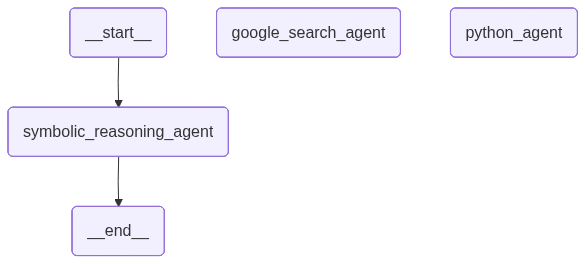

In [11]:
from IPython.display import Image, display
try:
    png_data = any_to_any_network.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(supervisor.get_graph().draw_ascii())

In [12]:
query = """Write a Python program that prints the any_to_any_network with all edges reversed."""

In [13]:
for event in any_to_any_network.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                       🤖 Agent: symbolic_reasoning_agent                                        ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: [symbolic_reasoning_agent → python_agent] Reason: The user has asked for a specific Python program    
that prints an any-to-any network with all edges reversed. I will delegate this task to the python_agent, which is 
best suited to execute and provide the code needed.

Python REPL can execute arbitrary code. Use with caution.


content='Original Network:\nA -> B\nA -> C\nB -> C\n\nReversed Network:\nB -> A\nC -> A\nC -> B\n' name='Python_REPL' tool_call_id='call_rV0BC5MioHit9G3o158k4Kli'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                             🤖 Agent: python_agent                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: Here is the Python program that defines an any-to-any network and prints it both in its original form 
and with all edges reversed:                                                                                       

                                                                                                                   
 class AnyToAnyNetwork:                                                                                            
     def __init__(self):                                                                                           
         self.graph = {}                                                                                           
                                                                                                                   
     def add_edge(self, src, dest):                                                                                
         if src not in self.graph:                                                                                 
             self.graph[src] = []                                                                                  
         self.graph[src].append(dest)                                                                              
                                                                                                                   
     def reverse_edges(self):                                                                                      
         reversed_graph = {}                                                                                       
         for src in self.graph:                                                                                    
             for dest in self.graph[src]:                                                                          
                 if dest not in reversed_graph:                                                                    
                     reversed_graph[dest] = []                                                                     
                 reversed_graph[dest].append(src)                                                                  
         self.graph = reversed_graph                                                                               
                                                                                                                   
     def print_network(self):                                                                                      
         for src in self.graph:                                                                                    
             for dest in self.graph[src]:                                                                          
                 print(f'{src} -> {dest}')                                                                         
                                                                                                                   
 # Example usage:                                                                                                  
 network = AnyToAnyNetwork()                                                                                       
 network.add_edge('A', 'B')                                                                                        
 network.add_edge('B', 'C')                                                                                        
 network.add_edge('A', 'C')                                                                                        
                                                        

In [14]:
query = """Using online real estate market data, find the average residential property price in Calgary for May 2026. 
Then analyze whether housing prices are likely to rise or fall during the Summer of 2026 and explain the key 
factors driving the trend. Cite your sources."""

In [15]:
for event in any_to_any_network.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                       🤖 Agent: symbolic_reasoning_agent                                        ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: [symbolic_reasoning_agent → google_search_agent] Reason: To provide accurate market data and future   
trends in Calgary real estate prices, I should delegate to the google_search_agent. This agent can access online   
databases and real-estate market reports to find the average residential property price for May 2026 and relevant  
trends influencing the housing market during that period.

INPUT TO TOOL: average residential property price in Calgary May 2026
INPUT TO TOOL: Calgary housing market trends summer 2026


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                          🤖 Agent: google_search_agent                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The average residential property price in Calgary for May 2026 is approximately $751,537. There are   
indications that housing prices may experience downward pressure in Summer 2026 due to factors such as an increase 
in housing supply, expected price declines forecasted for various property types, and broader economic conditions  
affecting the market.

# Supervisor Multi-Agents

Unlike an any-to-any network—where each agent has full autonomy to pass the entire conversation history to any other agent at any time—a Supervisor Network introduces a centralized supervisor agent that orchestrates and coordinates all interactions among sub-agents. In this architecture, the supervisor is responsible for task delegation, routing decisions, and overall workflow management, while sub-agents focus exclusively on executing the tasks assigned to them.

Because routing decisions are critical to system performance, the supervisor should be powered by a stronger model; incorrect routing can significantly degrade the overall workflow. In contrast, sub-agents typically use lightweight models to perform execution tasks efficiently, reducing both cost and latency.

Below is a LangGraph implementation of a Supervisor Network architecture.

In [16]:
# -------------------------------------------------------------------
# 🔷 MODEL INITIALIZATION
# -------------------------------------------------------------------

# Supervisor model:
# Uses a stronger model because it is responsible for routing decisions.
# If the supervisor chooses the wrong agent, the whole workflow degrades.
supervisor_model = ChatOpenAI(model='gpt-4.1-mini')  # or 'gpt-4.1' for higher accuracy

# Worker model:
# Lightweight model used by sub-agents for execution tasks.
# This reduces cost and latency.
model = ChatOpenAI(model='gpt-4o-mini')

# -------------------------------------------------------------------
# 🔷 SUPERVISOR SYSTEM PROMPT
# -------------------------------------------------------------------

# This prompt defines the supervisor’s role:
# - It does NOT solve the task itself
# - It ONLY decides which agent should act next
# - It must select from a fixed set of agents

supervisor_system_prompt = """
You are a supervisor coordinating a team of specialized agents.
Based on the user's request, decide which agent should handle the next step.

Your job is to:
1. Determine whether the task is already completed
2. If completed -> choose END
3. Otherwise choose the next best agent

Do NOT continue tool usage if:
- the answer already exists
- calculations are complete
- only minor refinement is possible

Prefer END over unnecessary extra work.

Available agents:

- symbolic_reasoning_agent: Handles logical reasoning, algebraic manipulation, derivations, and problem decomposition
- google_search_agent: Retrieves real-time or up-to-date information from the web
- python_agent: Executes Python code
- END: Select this when the task is complete
"""

In [17]:
# -------------------------------------------------------------------
# 🔷 SUPERVISOR NODE (ROUTER)
# -------------------------------------------------------------------

# The supervisor is responsible for deciding which agent should act next.
# Input  : MessagesState (full conversation history)
# Output : Command (controls graph execution flow)

def supervisor(state: MessagesState) -> Command[
    Literal["symbolic_reasoning_agent", "google_search_agent", "python_agent", END]
]:
    
    # Structured schema to enforce consistent LLM output
    class SupervisorResponse(BaseModel):
        next_agent_reasoning: str  # explanation of decision
        next_agent: Literal[
            "symbolic_reasoning_agent", 
            "google_search_agent", 
            "python_agent", 
            "END"
        ]

        # Final answer to user when workflow is complete
        final_response: str | None = None      
            

    # Wrap LLM to return structured output instead of free text
    structured_supervisor = supervisor_model.with_structured_output(SupervisorResponse)

    # Provide system instructions + full conversation history
    response = structured_supervisor.invoke(
        [SystemMessage(content=supervisor_system_prompt)] + state["messages"]
    )


    # If workflow is finished
    if response.next_agent == "END":
        return Command(goto=END, update={"messages": [AIMessage(content=response.final_response 
                                                                or "Task completed.")]})
    
    # Otherwise continue routing
    return Command(
        goto=response.next_agent,
        update={"messages": AIMessage(content=response.next_agent_reasoning)}
    )


# -------------------------------------------------------------------
# 🔷 MATH AGENT NODE
# -------------------------------------------------------------------

# Handles numerical and symbolic computations
def symbolic_reasoning_agent(state: MessagesState) -> Command[Literal["supervisor"]]:
    
    # Create a ReAct-style agent using configured model, tools, and prompt
    agent = create_react_agent(
        agents['symbolic_reasoning_agent'][0],
        agents['symbolic_reasoning_agent'][1],
        prompt=agents['symbolic_reasoning_agent'][3]
    )

    # Execute agent with current state
    response = agent.invoke(state)

    # Return result and hand control back to supervisor
    return Command(
        goto="supervisor",
        update={"messages": response["messages"]},
    )


# -------------------------------------------------------------------
# 🔷 GOOGLE SEARCH AGENT NODE
# -------------------------------------------------------------------

# Retrieves information from the web and answers questions
def google_search_agent(state: MessagesState) -> Command[Literal["supervisor"]]:
    
    agent = create_react_agent(
        agents['google_search_agent'][0],
        agents['google_search_agent'][1],
        prompt=agents['google_search_agent'][3]
    )

    response = agent.invoke(state)

    return Command(
        goto="supervisor",
        update={"messages": response["messages"]},
    )


# -------------------------------------------------------------------
# 🔷 PYTHON REPL AGENT NODE
# -------------------------------------------------------------------

# Executes Python code and returns results
def python_agent(state: MessagesState) -> Command[Literal["supervisor"]]:
    
    agent = create_react_agent(
        agents['python_agent'][0],
        agents['python_agent'][1],
        prompt=agents['python_agent'][3]
    )

    response = agent.invoke(state)

    return Command(
        goto="supervisor",
        update={"messages": response["messages"]},
    )


# -------------------------------------------------------------------
# 🔷 GRAPH CONSTRUCTION
# -------------------------------------------------------------------

# Initialize graph with shared message state
builder = StateGraph(MessagesState)

# Register nodes (each node = one agent or supervisor)
builder.add_node(supervisor)
builder.add_node(symbolic_reasoning_agent)
builder.add_node(google_search_agent)
builder.add_node(python_agent)

# Entry point: all requests start at the supervisor
builder.add_edge(START, "supervisor")

# Compile graph into executable workflow
supervisor = builder.compile()

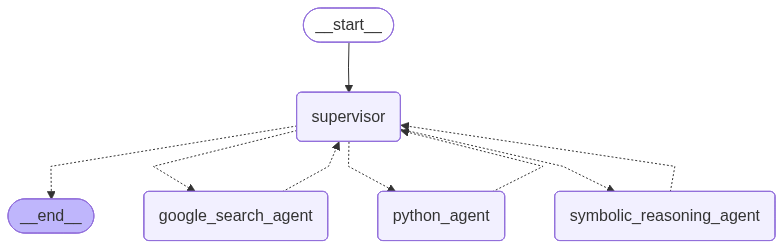

In [18]:
from IPython.display import Image, display
try:
    png_data = supervisor.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(supervisor.get_graph().draw_ascii())

In [19]:
query = """
Using current online real estate market data, find the average residential property price in Calgary for June 2026.

Then write a Python program that stores the price in a variable and calculates the price after a 2% increase.
"""

In [20]:
for event in supervisor.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the average residential property price in Calgary for June 2026, which requires     
accessing current online real estate market data projections or estimates for a future date. Since this information
is forward-looking and not typically in a static database, it requires real-time or updated online information.    
Therefore, the next best agent is google_search_agent to find this data. After that, the python_agent can be used  
to write the program for the calculation.

INPUT TO TOOL: average residential property price in Calgary June 2026


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                          🤖 Agent: google_search_agent                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the average residential property price in Calgary for June 2026, which requires     
accessing current online real estate market data projections or estimates for a future date. Since this information
is forward-looking and not typically in a static database, it requires real-time or updated online information.    
Therefore, the next best agent is google_search_agent to find this data. After that, the python_agent can be used  
to write the program for the calculation.                                                                          

🔧 Tool: google_search_scrape | Args: {'input_str': 'average residential property price in Calgary June 2026'}     

⚙️ Tool Result: Title: Calgary Housing Market | 2026 Home Prices Link:                                              
https://www.nesto.ca/real-estate/calgary-housing-market-outlook/ Snippet: Calgary Housing Market Highlights. The   
average selling price of a home in Calgary decreased by 2.2% year-over-year to $570,600 in April.                  

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary home values relatively flat in 2026 after significant ... Link:                                     
https://www.cbc.ca/news/canada/calgary/calgary-home-values-relatively-flat-in-2026-after-significant-spike-last-yea
r-9.7046864 Snippet: Single-family homes saw a one per cent increase, with the median value now $706,000 compared  
to $697,000 in 2025, according to the city. Condos ...                                                             

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary Housing Market Report: May. 6th, 2026 Update Link: https://wowa.ca/calgary-housing-market Snippet:  
The average home price of $651,895 was up 0.8% year-over-year and rose 1.6% from March. The median price of        
$586,000 declined 0.7% year-over-year and rose 1.6% ...                                                            

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The average residential property price in Calgary for May 2026 is reported to be approximately        
$651,895. However, specific data for June 2026 is not presented in the search results. To calculate a potential    
price increase based on the May price, you could assume a similar figure for June.                                 

If you would like a Python program to store this price and calculate the price after a 2% increase, a relevant     
solution can be provided, but the implementation cannot be included here.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The next step is to write a Python program that stores the given price (approximately $651,895 from   
the closest date, May 2026) and computes the price after a 2% increase.

content='' name='Python_REPL' tool_call_id='call_QfUkIMJlS2HH15BQUN76TPC7'content='664932.9\n' name='Python_REPL' tool_call_id='call_Yb9pgJvZeG7aDPdF5fPeIEAh'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                             🤖 Agent: python_agent                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the average residential property price in Calgary for June 2026, which requires     
accessing current online real estate market data projections or estimates for a future date. Since this information
is forward-looking and not typically in a static database, it requires real-time or updated online information.    
Therefore, the next best agent is google_search_agent to find this data. After that, the python_agent can be used  
to write the program for the calculation.                                                                          

🔧 Tool: google_search_scrape | Args: {'input_str': 'average residential property price in Calgary June 2026'}     

⚙️ Tool Result: Title: Calgary Housing Market | 2026 Home Prices Link:                                              
https://www.nesto.ca/real-estate/calgary-housing-market-outlook/ Snippet: Calgary Housing Market Highlights. The   
average selling price of a home in Calgary decreased by 2.2% year-over-year to $570,600 in April.                  

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary home values relatively flat in 2026 after significant ... Link:                                     
https://www.cbc.ca/news/canada/calgary/calgary-home-values-relatively-flat-in-2026-after-significant-spike-last-yea
r-9.7046864 Snippet: Single-family homes saw a one per cent increase, with the median value now $706,000 compared  
to $697,000 in 2025, according to the city. Condos ...                                                             

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary Housing Market Report: May. 6th, 2026 Update Link: https://wowa.ca/calgary-housing-market Snippet:  
The average home price of $651,895 was up 0.8% year-over-year and rose 1.6% from March. The median price of        
$586,000 declined 0.7% year-over-year and rose 1.6% ...                                                            

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The average residential property price in Calgary for May 2026 is reported to be approximately        
$651,895. However, specific data for June 2026 is not presented in the search results. To calculate a potential    
price increase based on the May price, you could assume a similar figure for June.                                 

If you would like a Python program to store this price and calculate the price after a 2% increase, a relevant     
solution can be provided, but the implementation cannot be included here.                                          

💬 Response: The next step is to write a Python program that stores the given price (approximately $651,895 from   
the closest date, May 2026) and computes the price after a 2% increase.                                            

🔧 Tool: Python_REPL | Args: {'query': '# Define the average residential property price\naverage_price =           
651895\n\n# Calculate the price after a 2% increase\nprice_after_increase = average_price * 1.02\n\n# Print the new
price\nprice_after_increase'}                                                                                      

⚙️ Tool Result:                                                                                                     

🔧 Tool: Python_REPL | Args: {'query': '# Define the average residential property price\naverage_price =           
651895\n\n# Calculate the price after a 2% increas

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The average residential property price in Calgary for May 2026 is approximately $651,895. Using a 2%  
increase, the price would be approximately $664,933. Here is a Python program that performs this calculation:      

                                                                                                                   
 # Define the average residential property price                                                                   
 average_price = 651895                                                                                            
                                                                                                                   
 # Calculate the price after a 2% increase                                                                         
 price_after_increase = average_price * 1.02                                                                       
                                                                                                                   
 # Print the new price                                                                                             
 print(price_after_increase)                                                                                       
                                                                                                                   

This program stores the price, calculates the 2% increase, and prints the new price.

In [21]:
from datetime import date

today = date.today()

query = f"""
Retrieve the maximum daytime temperature in Calgary for May in Fahrenheit using online data.
Then multiply the value by 234,567,821. Finally write a Python code that prints the result in the format:
"Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is ..."
"""

for event in supervisor.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the maximum daytime temperature in Calgary for May in Fahrenheit, explicitly from   
online data, which requires real-time information retrieval. After acquiring the data, the user wants it multiplied
by 234,567,821 and a Python code that prints this result accordingly. The first step is to get the temperature     
value from online data, so the next agent should be google_search_agent.

INPUT TO TOOL: maximum daytime temperature in Calgary for May in Fahrenheit


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                          🤖 Agent: google_search_agent                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the maximum daytime temperature in Calgary for May in Fahrenheit, explicitly from   
online data, which requires real-time information retrieval. After acquiring the data, the user wants it multiplied
by 234,567,821 and a Python code that prints this result accordingly. The first step is to get the temperature     
value from online data, so the next agent should be google_search_agent.                                           

🔧 Tool: google_search_scrape | Args: {'input_str': 'maximum daytime temperature in Calgary for May in Fahrenheit'}

⚙️ Tool Result: Title: Calgary May Weather, Average Temperature (Alberta, ... Link:                                 
https://weatherspark.com/m/2349/5/Average-Weather-in-May-in-Calgary-Alberta-Canada Snippet: May weather in Calgary 
Alberta, Canada. Daily high temperatures increase by 7°F, from 58°F to 65°F, rarely falling below 44°F or exceeding
77°F.                                                                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary, Alberta, Canada Monthly Weather Link:                                                              
https://www.accuweather.com/en/ca/calgary/t2p/may-weather/52479 Snippet: Calgary's May 2026 forecast shows daily   
high temperatures ranging from 47° to 69°, with overnight lows between 41° and 48°. The average high for May is 57°
...                                                                                                                

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary in May: Weather, Average temperature and Climate Link:                                              
https://avionero.com/New-York_NYC-Calgary_YYC/weather/may Snippet: The temperature in May is +73°F on average, with
a range between a maximum of +86°F during the day and a minimum of +37°F at night. The average maximum ...         

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The maximum daytime temperature in Calgary for May ranges from 65°F to 77°F. The specific temperature 
required is not directly stated as a single value, but it indicates that the maximum can reach up to 77°F.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The snippet indicates that the maximum daytime temperature in May in Calgary can go up to 77°F. We now
have the temperature value needed to proceed with the calculation and Python code generation. Therefore, we should 
use the python_agent to calculate the multiplication and generate the Python code that prints the result as        
requested.

content='SyntaxError("unmatched \'}\'", (\'<string>\', 3, 109, "print(f\'Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is {result}\')}", 3, 109))' name='Python_REPL' tool_call_id='call_fguaAomMal3wr7WDcccieiy2'content='Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is 18061722217\n' name='Python_REPL' tool_call_id='call_5uaE8DaWFcLUmtwLbVYJzkY3'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                             🤖 Agent: python_agent                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the maximum daytime temperature in Calgary for May in Fahrenheit, explicitly from   
online data, which requires real-time information retrieval. After acquiring the data, the user wants it multiplied
by 234,567,821 and a Python code that prints this result accordingly. The first step is to get the temperature     
value from online data, so the next agent should be google_search_agent.                                           

🔧 Tool: google_search_scrape | Args: {'input_str': 'maximum daytime temperature in Calgary for May in Fahrenheit'}

⚙️ Tool Result: Title: Calgary May Weather, Average Temperature (Alberta, ... Link:                                 
https://weatherspark.com/m/2349/5/Average-Weather-in-May-in-Calgary-Alberta-Canada Snippet: May weather in Calgary 
Alberta, Canada. Daily high temperatures increase by 7°F, from 58°F to 65°F, rarely falling below 44°F or exceeding
77°F.                                                                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary, Alberta, Canada Monthly Weather Link:                                                              
https://www.accuweather.com/en/ca/calgary/t2p/may-weather/52479 Snippet: Calgary's May 2026 forecast shows daily   
high temperatures ranging from 47° to 69°, with overnight lows between 41° and 48°. The average high for May is 57°
...                                                                                                                

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary in May: Weather, Average temperature and Climate Link:                                              
https://avionero.com/New-York_NYC-Calgary_YYC/weather/may Snippet: The temperature in May is +73°F on average, with
a range between a maximum of +86°F during the day and a minimum of +37°F at night. The average maximum ...         

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The maximum daytime temperature in Calgary for May ranges from 65°F to 77°F. The specific temperature 
required is not directly stated as a single value, but it indicates that the maximum can reach up to 77°F.         

💬 Response: The snippet indicates that the maximum daytime temperature in May in Calgary can go up to 77°F. We now
have the temperature value needed to proceed with the calculation and Python code generation. Therefore, we should 
use the python_agent to calculate the multiplication and generate the Python code that prints the result as        
requested.                                                                                                         

🔧 Tool: Python_REPL | Args: {'query': "max_temp = 77\nresult = max_temp * 234567821\nprint(f'Maximum daytime      
temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is {result}')}"}                            


⚙️ Tool Result: SyntaxError("unmatched '}'", ('', 3, 109, "print(f'Maximum daytime temperature in Calgary for May in
Fahrenheit multiplied by 234,567,821 is {result}')}", 3, 109))                                                     

🔧 Tool: Python_REPL | Args: {'query': "max_temp = 77\nresult = max_temp * 234567821\nprint(f'Maximum daytime      
temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is {result}')"}                             

⚙️ Tool Result: Maximum daytime temperature in Ca

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: Maximum daytime temperature in Calgary for May in Fahrenheit is 77°F.                                 

The multiplication of this temperature by 234,567,821 results in 18,061,722,217.                                   

Here is the Python code that prints this result:                                                                   

                                                                                                                   
 max_temp = 77                                                                                                     
 result = max_temp * 234567821                                                                                     
 print(f'Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is {result}')      
                                                                                                                   

As can be seen, one of the challenges with supervisor-based architectures is that the entire context is passed between agents. Because every agent can access the full conversation and intermediate results, an agent may start performing tasks that should belong to another specialized agent. This is one reason why some practitioners argue that a pure tool-calling system can sometimes be simpler and more controllable.

This illustrates a key drawback of full context sharing: agents can see that previous steps are already completed and may still **continue reasoning or executing unnecessary actions.**

Overall, this represents the basic structure of a supervisor network:

* Supervisor delegates work to a sub-agent,
* Full context is passed to the sub-agent,
* Sub-agent performs its task and returns the result to the Supervisor,
* and Supervisor decides what action to take next.


# Supervisor Tool Calling Multi-Agents

A Supervisor Tool-Calling Multi-Agent System is an architecture in which a central LLM (the supervisor) dynamically selects and invokes specialized tools to handle a user’s request.

In this tool-calling setup, the workflow is organized around tools rather than explicit graph nodes, where tools may wrap agents such as `symbolic_reasoning_agent`, `google_search_agent`, and `python_agent`. The final response is typically derived from the last message produced during execution.

The supervisor is responsible for deciding which tool to call at each step, with each tool acting as a ReAct-style component focused on a specific task. When a query is received, the supervisor routes it to the most appropriate tool and may chain multiple calls if needed. The key objective of this architecture is to efficiently route context to the correct tool to achieve accurate and structured problem solving.

If the system is composed of **smaller, specialized sub-agents, a tool-calling supervisor architecture is often the best approach**. On the other hand, if every agent is already highly capable — for example, powered by advanced reasoning models such as GPT-5 or Claude 4.1 — then an any-to-any network may work effectively without requiring strict orchestration. Even in those cases, however, a supervisor network can still improve efficiency by giving you greater control over context routing and information flow between agents.

In [35]:
supervisor_with_tools_prompt = """
You are a supervisor responsible for managing a team of specialized agents. 
Based on the user's request, determine which agent should handle the task next.

Available agents (implemented as tools):

1. symbolic_reasoning_agent
   - Handles logical reasoning, algebraic manipulation, derivations, and problem decomposition

2. google_search_agent
   - Retrieves and answers questions using up-to-date information from Google Search.

3. python_agent
   - Executes Python code and returns the output.

Instructions:
- Carefully analyze the user's request before selecting a tool.
- Route the task to the most appropriate agent.
- If multiple steps are required, call agents sequentially as needed.
- Return the final response clearly and concisely.
"""

In [70]:
# Handle logical reasoning, algebraic manipulation
@tool
def symbolic_reasoning_tool(task: str) -> str:
    """Handle logical reasoning, algebraic manipulation, derivations, and problem decomposition."""
    
    # Create a ReAct-style agent using configured model, tools, and prompt
    agent = create_react_agent(agents['symbolic_reasoning_agent'][0], agents['symbolic_reasoning_agent'][1], prompt=agents['symbolic_reasoning_agent'][3])

    # Invoke tool
    response = agent.invoke({'messages': [HumanMessage(content=task)]})
    return response['messages'][-1].content


# Retrieves information from the web and answers questions
@tool
def google_search_tool(task: str) -> str:
    """Retrieves and answers questions using up-to-date information from Google search."""
    
    agent = create_react_agent(agents['google_search_agent'][0], 
                               agents['google_search_agent'][1], 
                               prompt=agents['google_search_agent'][3])

    # Invoke tool
    response = agent.invoke({'messages': [HumanMessage(content=task)]})
    return response['messages'][-1].content


# Executes Python code and returns results
@tool
def python_tool(task: str) -> str:
    """Executes Python code and returns the result."""
    
    agent = create_react_agent(agents['python_agent'][0], 
                               agents['python_agent'][1], 
                               prompt=agents['python_agent'][3])

    # Invoke tool
    response = agent.invoke({'messages': [HumanMessage(content=task)]})
    return response['messages'][-1].content


In [73]:
tools = [symbolic_reasoning_tool, google_search_tool, python_tool]
# the simplest way to build a supervisor w/ tool-calling is to use prebuilt ReAct agent graph
# that consists of a tool-calling LLM node (i.e. supervisor) and a tool-executing node
supervisor_with_tools = create_react_agent(model, tools, prompt=supervisor_with_tools_prompt, name="my_custom_agent_name")

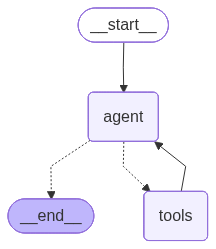

In [74]:
from IPython.display import Image, display

png_data = supervisor_with_tools.get_graph().draw_mermaid_png()
display(Image(png_data))

In [88]:
query = """Write a Python code that prints letter of a word in reversed order."""

In [89]:
for event in supervisor_with_tools.stream({"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

🔧 Tool: python_tool | Args: {'task': "print('hello'[::-1])"}

content='olleh\n' name='Python_REPL' tool_call_id='call_I5qaNs5u3BwVhhYsr3yiBY4c'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: tools                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

⚙️ Tool Result: The output is: olleh

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The Python code that prints the letters of the word "hello" in reversed order is:                     

                                                                                                                   
 print('hello'[::-1])                                                                                              
                                                                                                                   

When executed, it outputs: olleh.

In [91]:
query = """
Using current online real estate market data, find the average residential property price in Calgary for June 2026.
Then write a Python program that stores the price in a variable and calculates the price after a 2% increase.
"""

In [92]:
for event in supervisor_with_tools.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

🔧 Tool: google_search_tool | Args: {'task': 'average residential property price in Calgary for June 2026'}        

🔧 Tool: python_tool | Args: {'task': 'price = average_price; price_after_increase = price * 1.02'}

INPUT TO TOOL: average residential property price in Calgary for June 2026
content='' name='Python_REPL' tool_call_id='call_dyTbQ4ppdfPZnI0gO7pIdLVe'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: tools                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

⚙️ Tool Result: The average home price in Calgary for June 2026 is approximately $651,895, with a slight increase   
from the previous year.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: tools                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

⚙️ Tool Result: The code is missing a value assignment for average_price. I used 100 as an example. The price after 
the increase is calculated, and the amount is 102.0. If you'd like me to run with a different value or proceed     
differently, let me know!

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The average residential property price in Calgary for June 2026 is approximately $651,895.            

Here is the Python code to calculate the price after a 2% increase:                                                

                                                                                                                   
 average_price = 651895  # average price in Calgary for June 2026                                                  
 price_after_increase = average_price * 1.02                                                                       
                                                                                                                   

After running this code, the price after the increase would be $663,233.90.

# Using MCP to Enhance Agent Capabilities

**Model Context Protocol (MCP)** invented by **Antropic** in November 2024, it grows until 2025 around the concept of standardizing of the way we pass information to LLM. MCP is an open standard designed to bridge AI agents with the world of data and tools, to plug in many different sources of context as making tools is pretty ad-hoc so developers write custom code or use specialized plugins for each data source or API.

MCP is not itself, code, framework or LLM, it is a set of rules that we are would agree to provide a resource and creat a server that itself holds context for LLM. Broadly speaking, MCP is valuable when you want **an LLM to interact with external systems, either by accessing information beyond its training data or by taking actions on your behalf.**

* **Context** refers to external data the LLM can use, such as web search results, databases, or internal company information that was not included during training.
* **Tools** are executable functions the LLM can call to perform tasks, such as creating a pull request, sending an email, querying APIs, or updating files.
* **Protocol** refers to a standardized set of rules that defines how an LLM application communicates with external tools, data sources, and services.

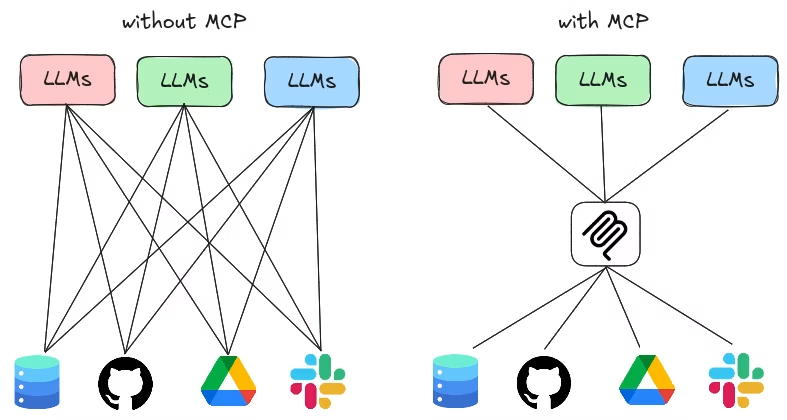
Source: https://hoangndst.com/blog/model-context-protocol

MCP provides three main components for LLMs: **Tools, Resources, and Prompts**. However, most attention is usually given to **Tools**, which define a standard way to build and share capabilities across systems.

A simple example: Person A builds an MCP server that exposes certain APIs as tools. They package it with required environment variables (like API keys) and open-source it. Now anyone—Person B, C, D, and others—can plug into this MCP server and instantly gain access to those tools without rebuilding the integration themselves.

In short, MCP enables reusable, shareable tool access where one provider can expose capabilities and many consumers can easily use them.

Extending this idea, an **MCP server** is responsible for providing functionality by connecting to external tools and data sources, while an **MCP client** is what consumes and interacts with those capabilities through a user interface or application layer.

For example, we can use **Streamlit**, a lightweight Python framework for building interactive web apps, to quickly create an MCP client UI. This allows us to focus on connecting to remote MCP servers and exploring different AI capabilities, while Streamlit handles the interface with minimal setup and fast prototyping.


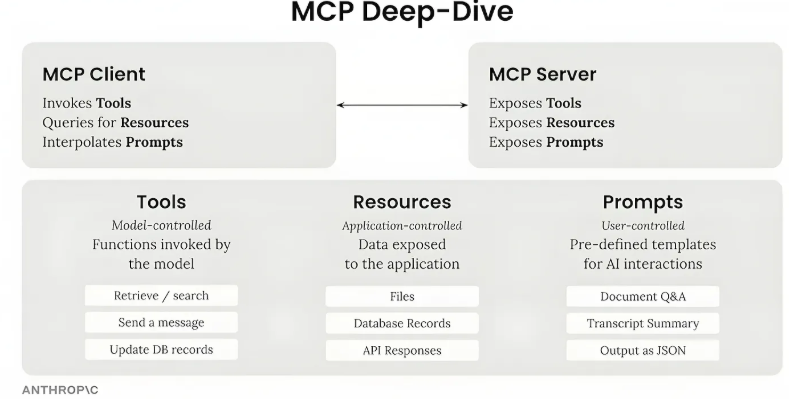
https://ppaolo.substack.com/p/how-anthropics-mcp-outshined-openais

A working MCP server can be very simple. Here, the FastMCP server is essentially a FastAPI-based server designed specifically for MCP resources, prompts, and tools. 

The code below shows a simple end-to-end functional MCP example.

In [ ]:
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("MCP Simple Example")

@mcp.tool()
def add_numbers(a: int, b: int) -> int:
    return a + b

# Show registered tools
print(mcp._tool_manager.list_tools())

Companies are building MCP servers for their own platforms — Notion has one, Zapier has one, and there are also several third-party MCP servers for Salesforce. This shows that building MCP servers is not limited to the companies that own the systems; developers and the broader community can build them as well.

For example, Zapier MCP lets your AI agent connect to thousands of apps through a standardized MCP interface. Instead of building separate integrations for each service, the AI simply uses Zapier’s MCP layer to access tools like email, messaging, spreadsheets, and CRMs in a unified way.

Briefly, the workflow is:

1. **Create a Zapier MCP server**:
   Zapier exposes actions from apps like Gmail, Slack, Google Sheets, and Notion as MCP tools.

2. **Connect the MCP server to your AI agent**:
   Your LLM application (for example using LangChain, LangGraph, or a custom agent) connects to the Zapier MCP endpoint.

3. **The AI discovers available tools automatically**:
   The agent can see available actions such as:

   * Send email
   * Create calendar event
   * Update spreadsheet
   * Post Slack message

4. **The AI calls tools when needed**:
   Example:

   * User says: “Send meeting notes to the team.”
   * AI decides to use Gmail + Slack tools through Zapier MCP.
   * Zapier executes the actions securely.

**This removes the need to manually build separate API integrations for every app.**

## LangGraph-Specific Setup

To make this concrete, let’s walk through a simple example of running an MCP-style tool integration in LangGraph and see how an agent can be granted access to external tools in practice.

In [ ]:
# A way to get a tool from langchain
from langchain_community.agent_toolkits.load_tools import load_tools
    
# Read API key from environment variable
os.environ["SERPAPI_API_KEY"] = os.getenv("SERP_API_KEY")  # https://serpapi.com for a free token!

tools = load_tools(["serpapi"])

In [ ]:
tools[0].run('Mehdi Rezvandehy')

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

# Use MemorySaver to save short term memory agent to remember who I am
agent_executor = create_react_agent(model, 
                                    tools, 
                                    checkpointer=MemorySaver())

In [ ]:
# Compile the graph
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [ ]:
query = "Who is Mehdi Rezvandehy, where does he work and what is his background."

response = agent_executor.invoke({"messages": [{"role": "user","content": query}]},
    config={"configurable": {"thread_id": "demo"}})

In [ ]:
response["messages"][-1].content

## Incorporating MCP into the architecture

An MCP server can run either:

1. **Locally** on your machine
2. **Remotely** on another server over HTTP

The AI agent does not really care where the MCP server is running. It only cares about:

* Connecting to the server
* Discovering tools
* Calling tools

A local MCP server runs on your own computer. The agent communicates directly with the local process.

Usually via:

* Stdio (`from mcp.client.stdio import stdio_client`)
* Local HTTP (`http://localhost:8000/mcp`)

* **Advantages of Local MCP**
  * Faster
  * More secure
  * No internet required
  * Can access local files/databases
  * Easier for development

* **Example Local Use Cases**

  * Filesystem tools
  * Local PDFs
  * Private company data
  * Local databases
  * Local Python execution  
  

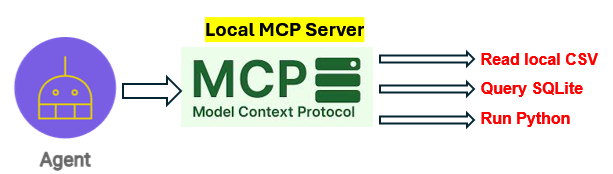

Here is an example of local server:
```python 
from mcp.client.stdio import stdio_client

async with stdio_client(server_params) as (
    read_stream,
    write_stream
)
```
This launches a local MCP process.

A remote MCP server runs somewhere else on the internet. For example, https://docs.devin.ai/work-with-devin/deepwiki-mcp is a remote MCP server.

* **Advantages of Remote MCP**
  * Shared by many users
  * Centralized tools
  * Easier deployment
  * Access cloud resources/APIs
  * No installation needed on client side

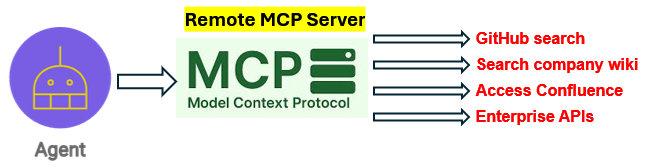

Here is an example of remote MCP server:
```python 
from mcp.client.streamable_http import streamablehttp_client

async with streamablehttp_client(
    "https://mcp.deepwiki.com/mcp"
)
```
This connects to a remote MCP endpoint.

See the examples below for the local and remote MCP server: 

### Local MCP Server 

In this example, we use LangGraph to build an agent and show how it connects to a local MCP server. This is not a universal standard for all platforms—it's simply one implementation approach based on LangGraph’s documented way of integrating with MCP.

In [ ]:
#!pip install langchain-mcp-adapters

In [ ]:
# Import necessary libraries
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain.agents import create_agent

# Use nest_asyncio because of using this into jupyter notebook
import nest_asyncio

# Apply nest_asyncio to handle nested event loops
nest_asyncio.apply()

In this setup, we configure a standard input/output (stdio) connection to communicate with an MCP server. The MCP client launches a local server process and communicates with it through `stdin/stdout`. This allows the client to treat the server as a subprocess that exposes tools via the MCP protocol.

The `server_params` object defines how the MCP server process should be started. Specifically, it specifies the Python interpreter to use and the path to the MCP server script. This script runs a local MCP server that exposes tools defined inside it.

Although this example runs locally, the same mechanism can be extended to remote servers or containerized deployments.

```python
from mcp import ClientSession, StdioServerParameters

server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)
```

An important concept here is the separation of responsibilities between the LLM host and the MCP server:

* The host application (the client running LangGraph) is responsible for invoking the LLM.
* The MCP server is responsible for executing the tools.

For example, if a tool relies on a SerpAPI key, the API key only needs to exist in the MCP server environment. The LLM itself does not need direct access to that key. This creates a clean separation between model execution and tool execution.

In other words:

* The LLM handles reasoning and tool selection.
* The MCP server handles the actual execution of external tools and APIs.

These components can even run in completely different environments. In the next lesson, we will demonstrate how MCP servers can run inside Docker containers. As long as the container has the required API keys and dependencies configured, LangGraph can communicate with it seamlessly.


* **Simple Exmaple 1**

Here is a simple MCP server, that is saved as `*.py` file as it is required for MC server.

In [ ]:
MCP_SERVER = f'''
from mcp.server.fastmcp import FastMCP
from langchain_community.utilities import SerpAPIWrapper
import os

mcp = FastMCP("Simple MCP Example")

# Register this function as a callable MCP tool.
@mcp.tool()
def multiply(a: float, b: float) -> int:
    """Multiply two float numbers"""
    return a * b

@mcp.tool()
def add(a: float, b: float) -> int:
    """Add two float numbers"""
    return a + b


@mcp.tool()
def google_search(query: str) -> str:
    """Apply Online Realtime Web Search"""
    serpapi = SerpAPIWrapper(serpapi_api_key="{os.getenv("SERP_API_KEY")}")
    return serpapi.run(query)

if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

mcp_path = 'mcp_server.py'

with open(mcp_path, 'w') as f:
    f.write(MCP_SERVER)

print("Saved to:", os.path.abspath(mcp_path))

The code below sets up an asynchronous pipeline that connects to a local MCP server (`mcp_server.py`) using a stdio subprocess. It starts the server, creates a session, and initializes communication. Then it loads all tools exposed by the MCP server and prints their metadata. These tools are passed into a LangGraph ReAct agent built on a ChatOpenAI model. Finally, the agent is executed asynchronously with memory support to process the user’s input query. The memory support saves the conversation state so it can remember previous messages in the same thread.

In [ ]:
import asyncio
import sys
import os

from langchain_openai import ChatOpenAI
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# Windows notebook asyncio fix
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# MCP server process config
server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)

# async means this function can run cooperatively with other tasks without blocking the program.
async def agent_run_async(m, thread_id="thread_id"):
    # Start MCP stdio connection
    async with stdio_client(server_params, errlog=None) as (read, write):

        # Create MCP session
        async with ClientSession(read, write) as session:

            # Initialize MCP connection
            await session.initialize()

            # Load MCP tools into LangGraph
            mcp_tools = await load_mcp_tools(session)

            # Print discovered tools
            for tool in mcp_tools:
                print(f'Tool Name: {tool.name}')
                print(f'Tool Description: {tool.description}')
                print(f'Tool Arguments Schema: {tool.args_schema}')
                print(f'Tool Response Format: {tool.response_format}')
                print('-' * 40)

            # Create agent with MCP tools
            agent = create_agent(
                llm,
                mcp_tools,
                checkpointer=MemorySaver()
            )

            # Run agent
            return await agent.ainvoke(
                {"messages": m},
                config={"configurable": {"thread_id": thread_id}}
            )

In [ ]:
agent_response = await agent_run_async("What is current home price on average for a detached house in Calgary times 12?", thread_id='my test')

In [ ]:
# Last message
agent_response['messages'][-1]

This code below is debugging / inspecting an LLM agent response (likely from LangGraph + MCP tool calling). It prints out a structured view of the model’s messages, especially focusing on tool calls made to an MCP server. **Looping over all messages produced by the agent**.

In [ ]:
for message in agent_response['messages']:
    print(type(message), message.content, 'Tool ID:' + message.tool_call_id if hasattr(message, 'tool_call_id') else '')
    if message.additional_kwargs.get('tool_calls'):
        for tool_call in message.additional_kwargs.get('tool_calls'):
            print(f'Tool Call: ID({tool_call["id"]}), Name({tool_call["function"]["name"]}), Args({tool_call["function"]["arguments"]})')
    print('----')

In [ ]:
len(agent_response['messages'])

* **Simple Exmaple 2**

Here is another local MCP server. This MCP server exposes a simple local filesystem toolset that lets an agent create and modify files inside a controlled workspace directory (`mcp_workspace`). It provides two tools: `create_file` to create a new file with optional content, and `write_file` to append content to an existing file. The server runs over stdio so it can be connected to by an MCP client or agent process.

In [ ]:
MCP_SERVER = '''

from mcp.server.fastmcp import FastMCP
import os

mcp = FastMCP("local-filesystem")

BASE_DIR = os.path.abspath("./mcp_workspace")

os.makedirs(BASE_DIR, exist_ok=True)


@mcp.tool()
# async means this function can run cooperatively with other tasks without blocking the program.
async def create_file(path: str, content: str = ""):
    full_path = os.path.join(BASE_DIR, path)

    os.makedirs(os.path.dirname(full_path), exist_ok=True)

    with open(full_path, "w", encoding="utf-8") as f:
        f.write(content)

    return {"status": "created", "path": full_path}


@mcp.tool()
async def write_file(path: str, content: str):
    full_path = os.path.join(BASE_DIR, path)

    with open(full_path, "a", encoding="utf-8") as f:
        f.write(content)

    return {"status": "written", "path": full_path}

@mcp.tool()
async def create_xy_file(n: int = 100):
    lines = ["x y"]
    for i in range(1, n+1):
        lines.append(f"{i} {n-i+1}")
    return "\\n".join(lines)
    
if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

mcp_path = 'mcp_server_1.py'

with open(mcp_path, 'w') as f:
    f.write(MCP_SERVER)

print("Saved to:", os.path.abspath(mcp_path))


In [ ]:
import asyncio
import sys

from langchain_openai import ChatOpenAI
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

# Windows notebook asyncio fix
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# MCP server process config
server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)

async def agent_run_async(m, thread_id="thread_id"):

    # Start MCP stdio connection
    async with stdio_client(server_params, errlog=None) as (read, write):

        # Create MCP session
        async with ClientSession(read, write) as session:

            # Initialize MCP connection
            await session.initialize()

            # Load MCP tools into LangGraph
            mcp_tools = await load_mcp_tools(session)

            # Print discovered tools
            for tool in mcp_tools:
                print(f'Tool Name: {tool.name}')
                print(f'Tool Description: {tool.description}')
                print(f'Tool Arguments Schema: {tool.args_schema}')
                print(f'Tool Response Format: {tool.response_format}')
                print('-' * 40)

            # Create agent with MCP tools
            agent = create_agent(
                llm,
                mcp_tools,
            #    checkpointer=MemorySaver()
            )

            # Run agent
            return await agent.ainvoke(
                {"messages": m},
                config={"configurable": {"thread_id": thread_id}}
            )


In [ ]:
prompt = """Create 10 text file named 'sample_1.txt' to 'sample_10.txt' each with 2 columns: x  y. 
- x column should have 100 rows: starts from 1 to 100 with 1 interval. 
- y column should have 100 rows: starts from 100 to 1 with 1 interval. 

each text file shoule be like this:
x     y    
1    100
.     .    
.     . 
100   1 
"""

agent_response = await agent_run_async(prompt, thread_id='my test')

In [ ]:
# Last message
agent_response['messages'][-1]

### Remote MCP Server

A remote MCP server is a cloud-hosted MCP server that lets AI agents connect to external tools and data over the internet using HTTP-based communication, instead of running locally on your computer. It acts like a standardized bridge between LLMs and services such as GitHub, databases, Slack, or cloud platforms. Remote MCP servers simplify integrations because clients can securely access tools through one common protocol rather than building custom APIs for every service.

Here is list of curated list of high quality remote MCP servers: https://mcpservers.org/remote-mcp-servers

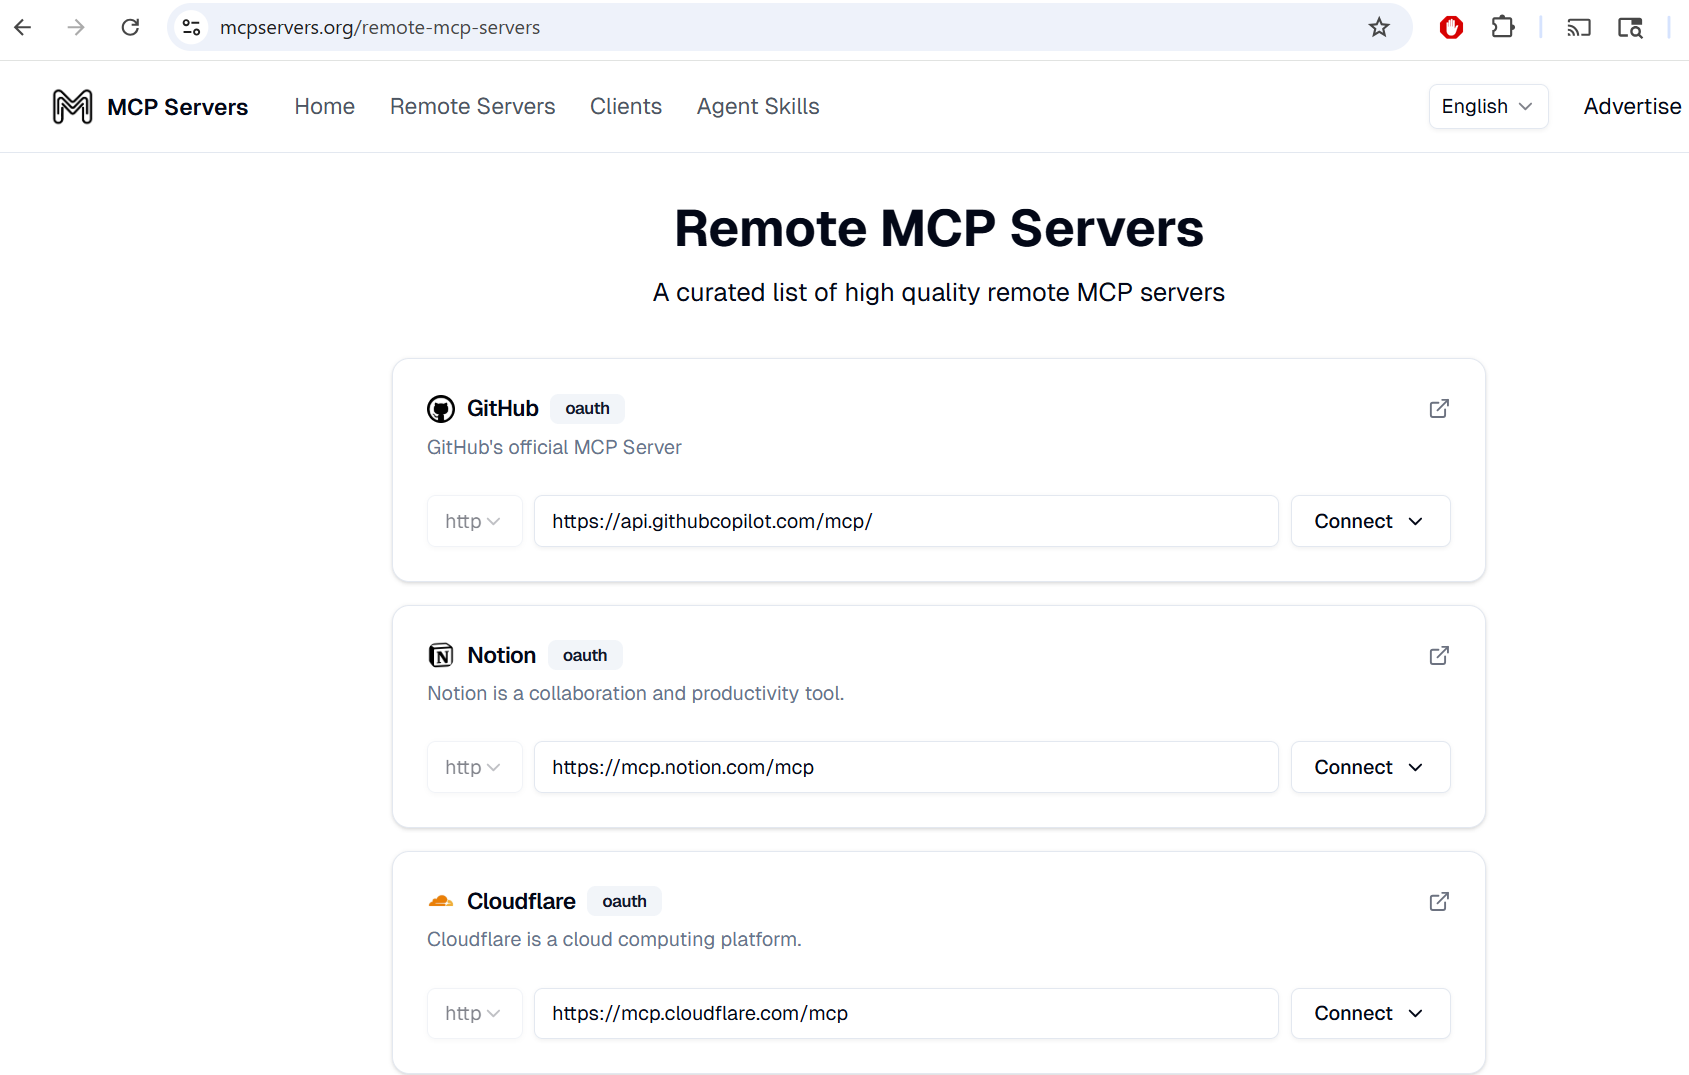

In [ ]:
from langchain_core.tools import StructuredTool
# Make MCP connection call only once
from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client

from langchain_core.tools import StructuredTool
from langchain.agents import create_agent

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

mcp_ctx = None
session = None
agent = None

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

In [ ]:
# Startup Function
async def startup():

    global mcp_ctx
    global session
    global agent

    mcp_ctx = streamablehttp_client(
        #"https://mcp.deepwiki.com/mcp"
        "https://mcp.devin.ai/mcp",  # Used to let an AI agent interact with repositories, create sessions, run workflows, manage issues, and orchestrate software development tasks.
    )

    read_stream, write_stream, _ = await mcp_ctx.__aenter__()

    session_ctx = ClientSession(
        read_stream,
        write_stream
    )

    session = await session_ctx.__aenter__()

    await session.initialize()

    tools_response = await session.list_tools()

    mcp_tools = []

    for t in tools_response.tools:

        tool_name = t.name

        async def mcp_tool(
            arguments: dict,
            tool_name=tool_name
        ):
            result = await session.call_tool(
                tool_name,
                arguments
            )

            return str(result.content)

        wrapped_tool = StructuredTool.from_function(
            func=mcp_tool,
            name=tool_name,
            description=f"MCP tool: {tool_name}"
        )

        mcp_tools.append(wrapped_tool)

    agent = create_agent(
        model=llm,
        tools=mcp_tools,
        checkpointer=memory
    )

    print("MCP Agent Ready")
    
    # Print discovered tools
    for tool in mcp_tools:
        print(f'Tool Name: {tool.name}')
        print(f'Tool Description: {tool.description}')
        print(f'Tool Arguments Schema: {tool.args_schema}')
        print(f'Tool Response Format: {tool.response_format}')
        print('-' * 40)

In [ ]:
await startup()

In [ ]:
async def agent_run_async(message, thread_id="default"):
        # Run agent
        return await agent.ainvoke(
            {"messages": message},
            config={"configurable": {"thread_id": thread_id}}
        )

In [ ]:
query = """
Explain this WIKI page https://en.wikipedia.org/wiki/Bandar-e_Anzali

"""

In [ ]:
agent_response = await agent_run_async(query, thread_id='my test')
agent_response

In [ ]:
# Last message
agent_response['messages'][-1]

In [ ]:
for message in agent_response['messages']:
    print(type(message), message.content, 'Tool ID:' + message.tool_call_id if hasattr(message, 'tool_call_id') else '')
    if message.additional_kwargs.get('tool_calls'):
        for tool_call in message.additional_kwargs.get('tool_calls'):
            print(f'Tool Call: ID({tool_call["id"]}), Name({tool_call["function"]["name"]}), Args({tool_call["function"]["arguments"]})')
    print('----')

# Summary

From the LLM’s perspective, **nothing has fundamentally changed**. It is still operating as a standard tool-calling model, interacting through human messages, AI messages, and tool messages exactly as before. The agent itself does not care whether an MCP server is running in the background. To the LLM, tools simply appear in the prompt, and it decides which tool to call.

The only real difference is **where the tool execution happens**. Instead of running locally or inside the application, the request is routed through an **MCP server**. For example, the LLM may decide to call a tool, LangGraph or LangChain converts that request into an MCP call, the **MCP server executes the tool**, and the result is returned back to the agent as a tool message. **From the LLM’s perspective, the workflow remains unchanged.**

Because of this, whether or not we use an MCP server is primarily a **development and architecture choice**. It does not change the LLM’s tool-calling capabilities, and it is irrelevant when evaluating whether the model itself can effectively use tools.

What MCP changes is the infrastructure layer. MCP provides a **standardized way to expose, share, and manage tools, prompts, and resources** across systems and organizations. While it still has limitations and evolving standards, it is becoming an important foundation for building interoperable AI agents and enabling collaboration between different applications and ecosystems.


This image compares AI architectures before and after the Model Context Protocol (MCP). Before MCP, LLMs needed separate custom integrations for every tool, creating complex “NxM” connections. With MCP, the LLM connects through a single unified interface, while MCP handles communication with external tools. This simplifies integration, improves scalability, and standardizes connectivity across AI systems.

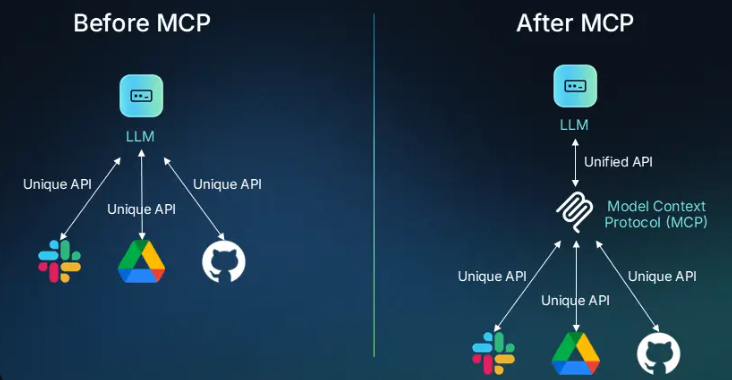

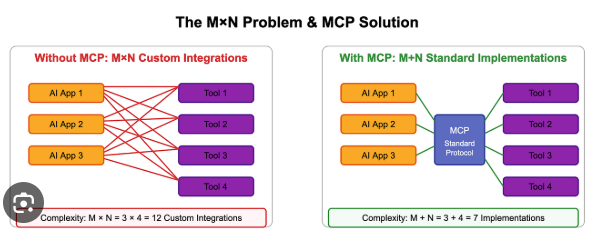

## Risk Using MCP

MCP is a powerful idea, but it is not without risks. For example, some MCP servers could potentially be misused to access sensitive or private information. However, this is not a flaw in MCP itself, nor is it a fault of platforms like GitHub. Rather, it reflects a broader challenge in how LLMs are granted access to external tools and how those tools are composed and chained together.

In many cases, security issues arise when tool access is not carefully scoped, and when combinations of tools can be orchestrated in unintended or malicious ways. For instance, there have been scenarios where an LLM, through a GitHub MCP integration, was able to interact with repositories it should not have had access to.

The key point is that everything in this stack has potential vulnerabilities—LLMs, MCP servers, and tool integrations. MCP itself is simply a standard for structuring and unifying tool calling in LLM systems. It does not inherently introduce the problem; rather, it defines a mechanism that can be misused if the underlying access controls and model behavior are not properly constrained.

In this sense, **the issue is less about MCP as a protocol and more about how LLMs interpret and execute tool usage in potentially adversarial contexts.**